<h2 style="color:Purple; font-family:; text-align:center;font-size:35px">
  ❁۪ ｡˚ Actividad 1: Inferencia estadística vs Aprendizaje de máquinas  ❁۪ ｡˚
</h2>
<h1 style="color:Purple; font-size:13.5px;"> Student: </h1>Ornella Cañellas Arredondo 
<h1 style="color:Purple; font-size:13.5px;"> Rol:  </h1>202387002-1
<h1 style="color:Purple; font-size:13.5px;"> Professor: </h1> Pía Amigo


<h2 style="color:Fuchsia; font-family:; text-align:center;font-size:20px">
  ❁۪ ｡˚ Parte 1: Ajuste de recta  ❁۪ ｡˚
</h2>

(Adaptado de  Viviana Acquaviva (2023))

In [14]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

In [15]:
#Estos parámetros son para generar figuras de alta calidad
font = {'size'   : 12}
matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=10) 
matplotlib.rc('ytick', labelsize=10) 
matplotlib.rcParams.update({'figure.autolayout': False})
matplotlib.rcParams['figure.dpi'] = 300

Para esta parte 1, se trata sobre la inferencia estadística y el acercamiento mismo a datos que sigan determinada relación. Como actividad inicial se generan datos que sigan una relación lineal involucrando ruido y aquello se utiliza como grilla para encontrar el mejor ajuste, luego con y sin considerar las incertezas. Puesto que hay una relativa incertidumbre relacionada a la inferencia a partir de los datos que se tomen en cuenta, el ajuste permitirá hacer una generalización que consecuentemente posibilita hacer una conclusión y conjunto al ajuste y datos explicitar la misma prueba en la muestra (las descripciones son extraídas a partir del marco para el pensamiento acerca de la inferencia estadística por Makar & Rubin (2009), pág. 85).

Para generar datos se considera el uso de np.random.seed(), que permite generar una "semilla" global para la reproducibilidad

In [16]:
np.random.seed(16) #semilla fija para reproducibilidad
x = np.arange(10) #en x se generan 10 datos del 0 al 9
y = 2*x + 5 + np.random.randn(10) #se generan datos con scatter (desviación) gaussiano
print(x,y)

[0 1 2 3 4 5 6 7 8 9] [ 5.12794872  5.47152654  8.40553202 11.06633037 11.76450513 14.37863139
 16.1110522  19.49890986 20.2131029  23.11874356]


Como situación física se puede tomar en cuenta el movimiento de un auto con rapidez constante, donde el $x$ es el tiempo (en segundos) e $y$ es la distancia recorrida (en metros).

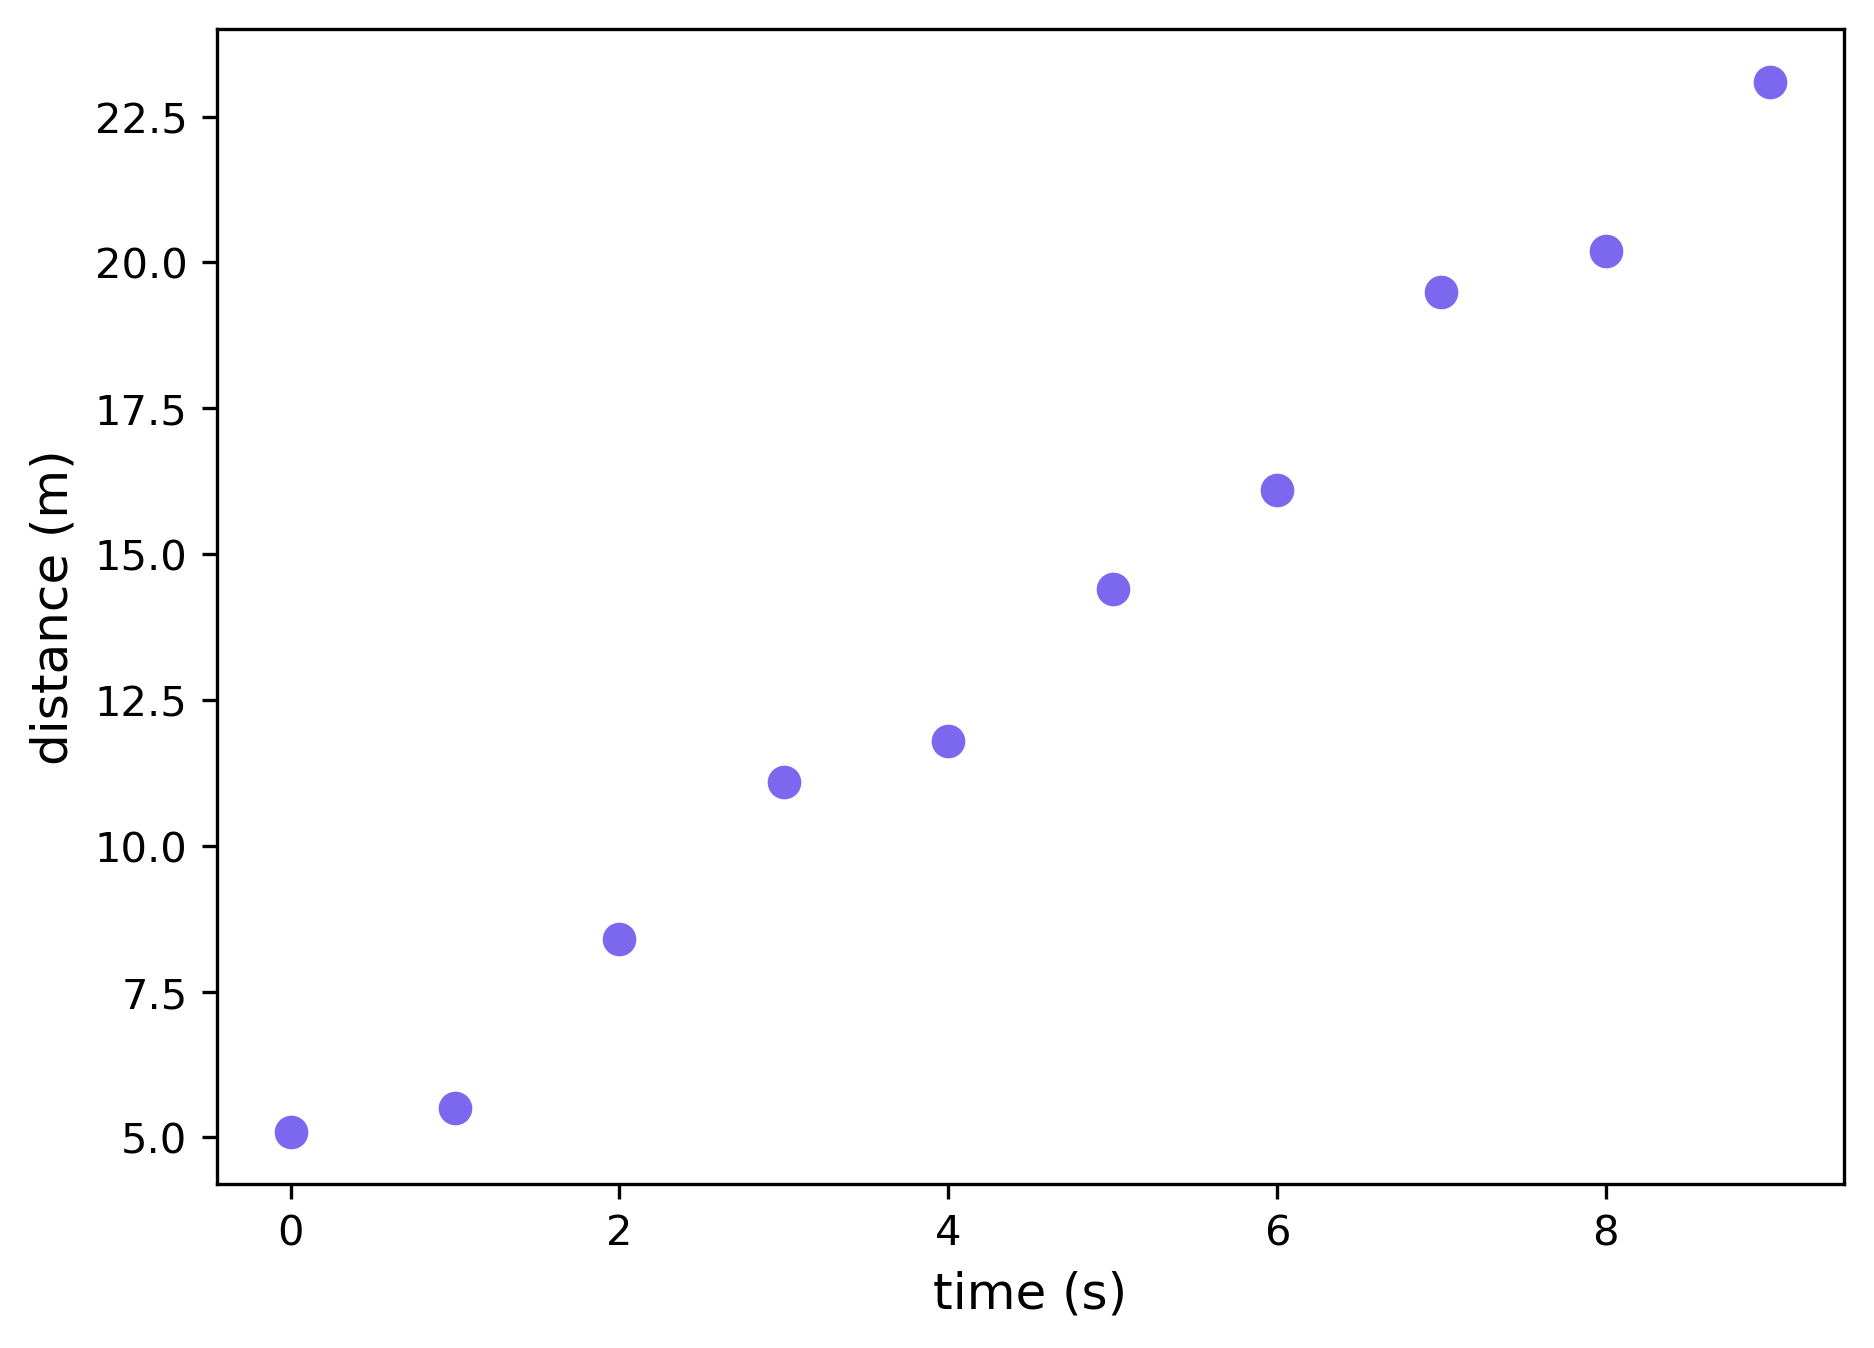

In [57]:
plt.figure(figsize=(7,5)) 
plt.scatter(x,y, c = 'mediumslateblue',s=50)
plt.xlabel('time (s)')
plt.ylabel('distance (m)');

In [22]:
x #aquí se muestra lo que contiene x como array

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [23]:
y = np.round(y,1) #aquí se muestran los datos de y dependientes de valores de x, redondeado a 1 décima

In [24]:
y

array([ 5.1,  5.5,  8.4, 11.1, 11.8, 14.4, 16.1, 19.5, 20.2, 23.1])

Con los datos anteriores, es decir, $x$ e $y$, se tiene que establecer (y decir) la distancia a la que estará el auto cuando $t=12$ s, entonces ¿cómo podemos resolver el problema?. Se procede a la inferencia para la relación distancia-tiempo. 

<h2 style="color:purple; font-family:; text-align:center;font-size:26px">
  ❁۪ ｡˚ Inferencia  ❁۪ ｡˚
</h2>

La relación establecida entre la distancia y tiempo, para una partícula con rapidez constante está dada por $$d=d_0 +vt$$. Dado que se tienen 2 parámetros $d_0$ y $v$. Se requiere encontrar aquellos para poder aplicar el modelo y poder determinar $d(t=12 s)$.

¿Cómo se podría hacer esto?

Con el hint dado, se puede considerar el error que proviene por los datos "no perfectamente calibrados", entonces al ajustar la recta hay una acumulación de errores, lo que es asimismo la suma de errores, y se consideran como la suma al cuadrado de las distancias. Esto es entre las distancias predichas por el modelo como $D^m_i$ y las que han sido observadas $D^o_i$, entonces $$\sum_{i=1}^{10}(D^m(d_0,v,x_i)-D^o_i)^2$$



esto puede entenderse también al hacer una analogía de laboratorio por ejemplo, como los datos hipotéticos (como distancias predichas) y datos experimentales (las distancias observadas).

<details>
<summary>Ayuda!</summary>
Podemos considerar el error en un ajuste de recta como la suma de errores, que consideramos la suma al cuadrado de las distancia entre las distancias predichas por el el modelo ($D^m_i$) y las observadas ($D^o_i$) $$\sum_{i=1}^{10}(D^m(d_0,v,x_i)-D^o_i)^2$$

Para los datos dados, se encuentran los parámetros mencionados, el intercepto como $d_0$ y $v$, la pendiente. Esto se puede hacer con polynomial, "comando" encontrado en un blog https://www-dribin-org.translate.goog/dave/blog/archives/2024/02/18/python-linear-fit/?_x_tr_sl=en&_x_tr_tl=es&_x_tr_hl=es&_x_tr_pto=tc

In [25]:
#Codigo aca!
#para encontrar el intercepto b y la pendiente m, hay dos formas
#la primera forma
b,m = np.polynomial.polynomial.Polynomial.fit(x,y,1).convert().coef
print("Intercepto (d_0):",b)
print("Pendiente (v)",m)

Intercepto (d_0): 4.301818181818184
Pendiente (v) 2.048484848484848


In [27]:
#la segunda forma (más eficiente de escribir)
b,m = np.polynomial.polynomial.polyfit(x,y,1)
print(b,m)

4.30181818181818 2.0484848484848492


**Luego, los valores de pendiente m e intercepto b encontrados son alrededor de 
- **bestm**: 4.301
- **bestb**: 2.048

Con este modelo, cuánto es $d(t=12s)$?**


In [29]:
#Usando el modelo, d(t=12 s) se puede calcular como
t=12
d=b+m*t
print("Valor de distancia para t=12 seconds:",d)
print("Valor redondeado:", round(d,1))

Valor de distancia para t=12 seconds: 28.883636363636374
Valor redondeado: 28.9


Entonces con los datos se encuentra el mejor ajuste interpolando los datos.

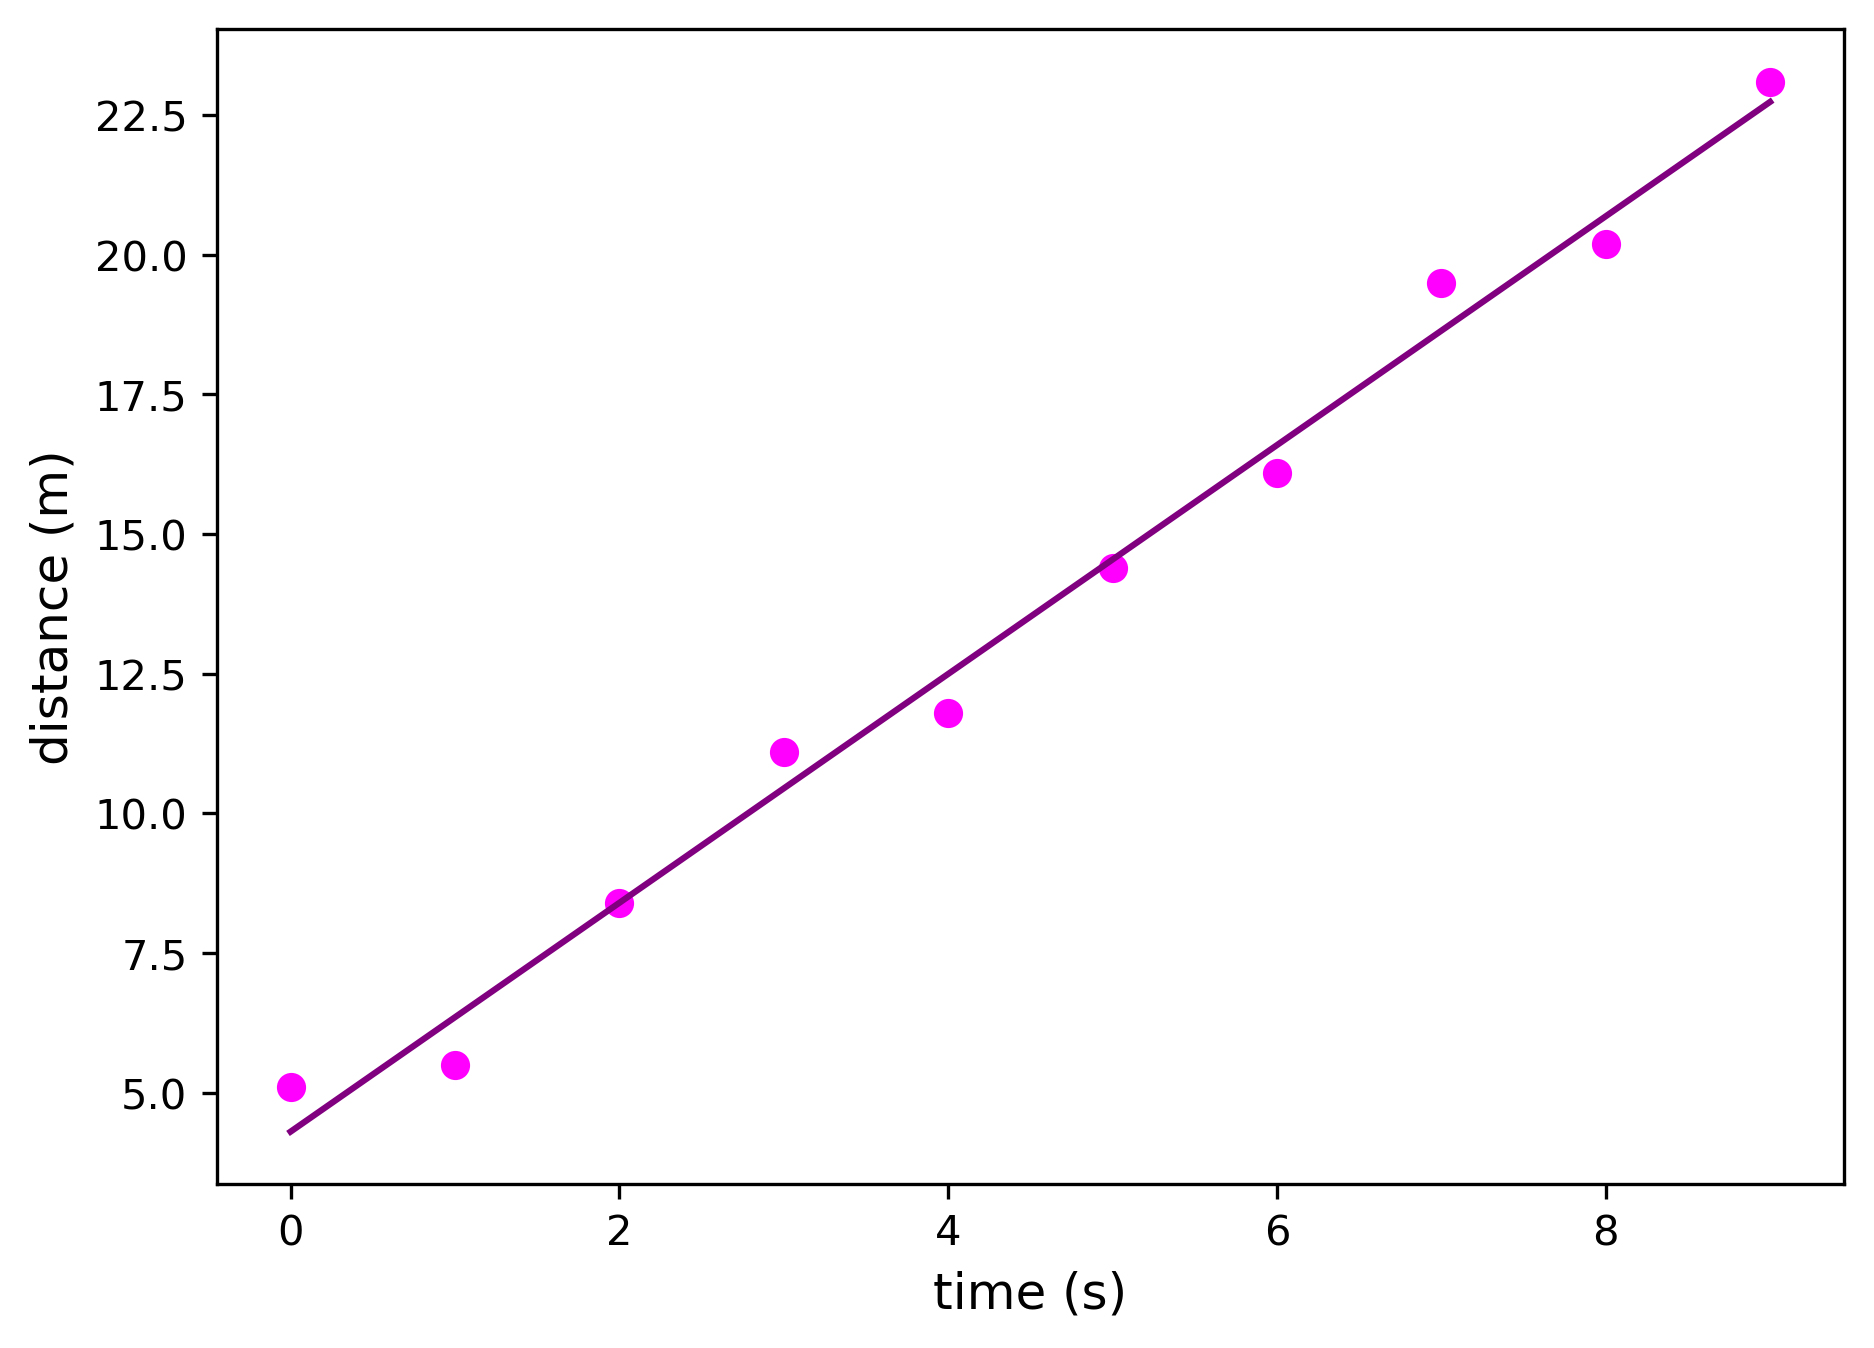

In [55]:
bestm=m
bestb=b
plt.figure(figsize=(7,5)) 
plt.scatter(x,y, c = 'fuchsia')
plt.xlabel('time (s)')
plt.ylabel('distance (m)')
plt.plot(x, bestm*x+bestb, c = 'purple'); #con esto se grafica la recta con los mejores parámetros

Además se puede agregar incerteza en la medición de distancias

In [47]:
np.random.seed(10) #nuevamente, la semilla fija para reproducibilidad
dy = np.random.randn(10)*np.sqrt(2) #agregamos incertezas aleatorias, el signo no importa

In [48]:
dy #se muestra el array de las incertezas que se generaron

array([ 1.88314769,  1.01155723, -2.18552605, -0.01185655,  0.87870176,
       -1.01835477,  0.37549009,  0.1535108 ,  0.006069  , -0.24692199])

Text(0, 0.5, 'distance (m)')

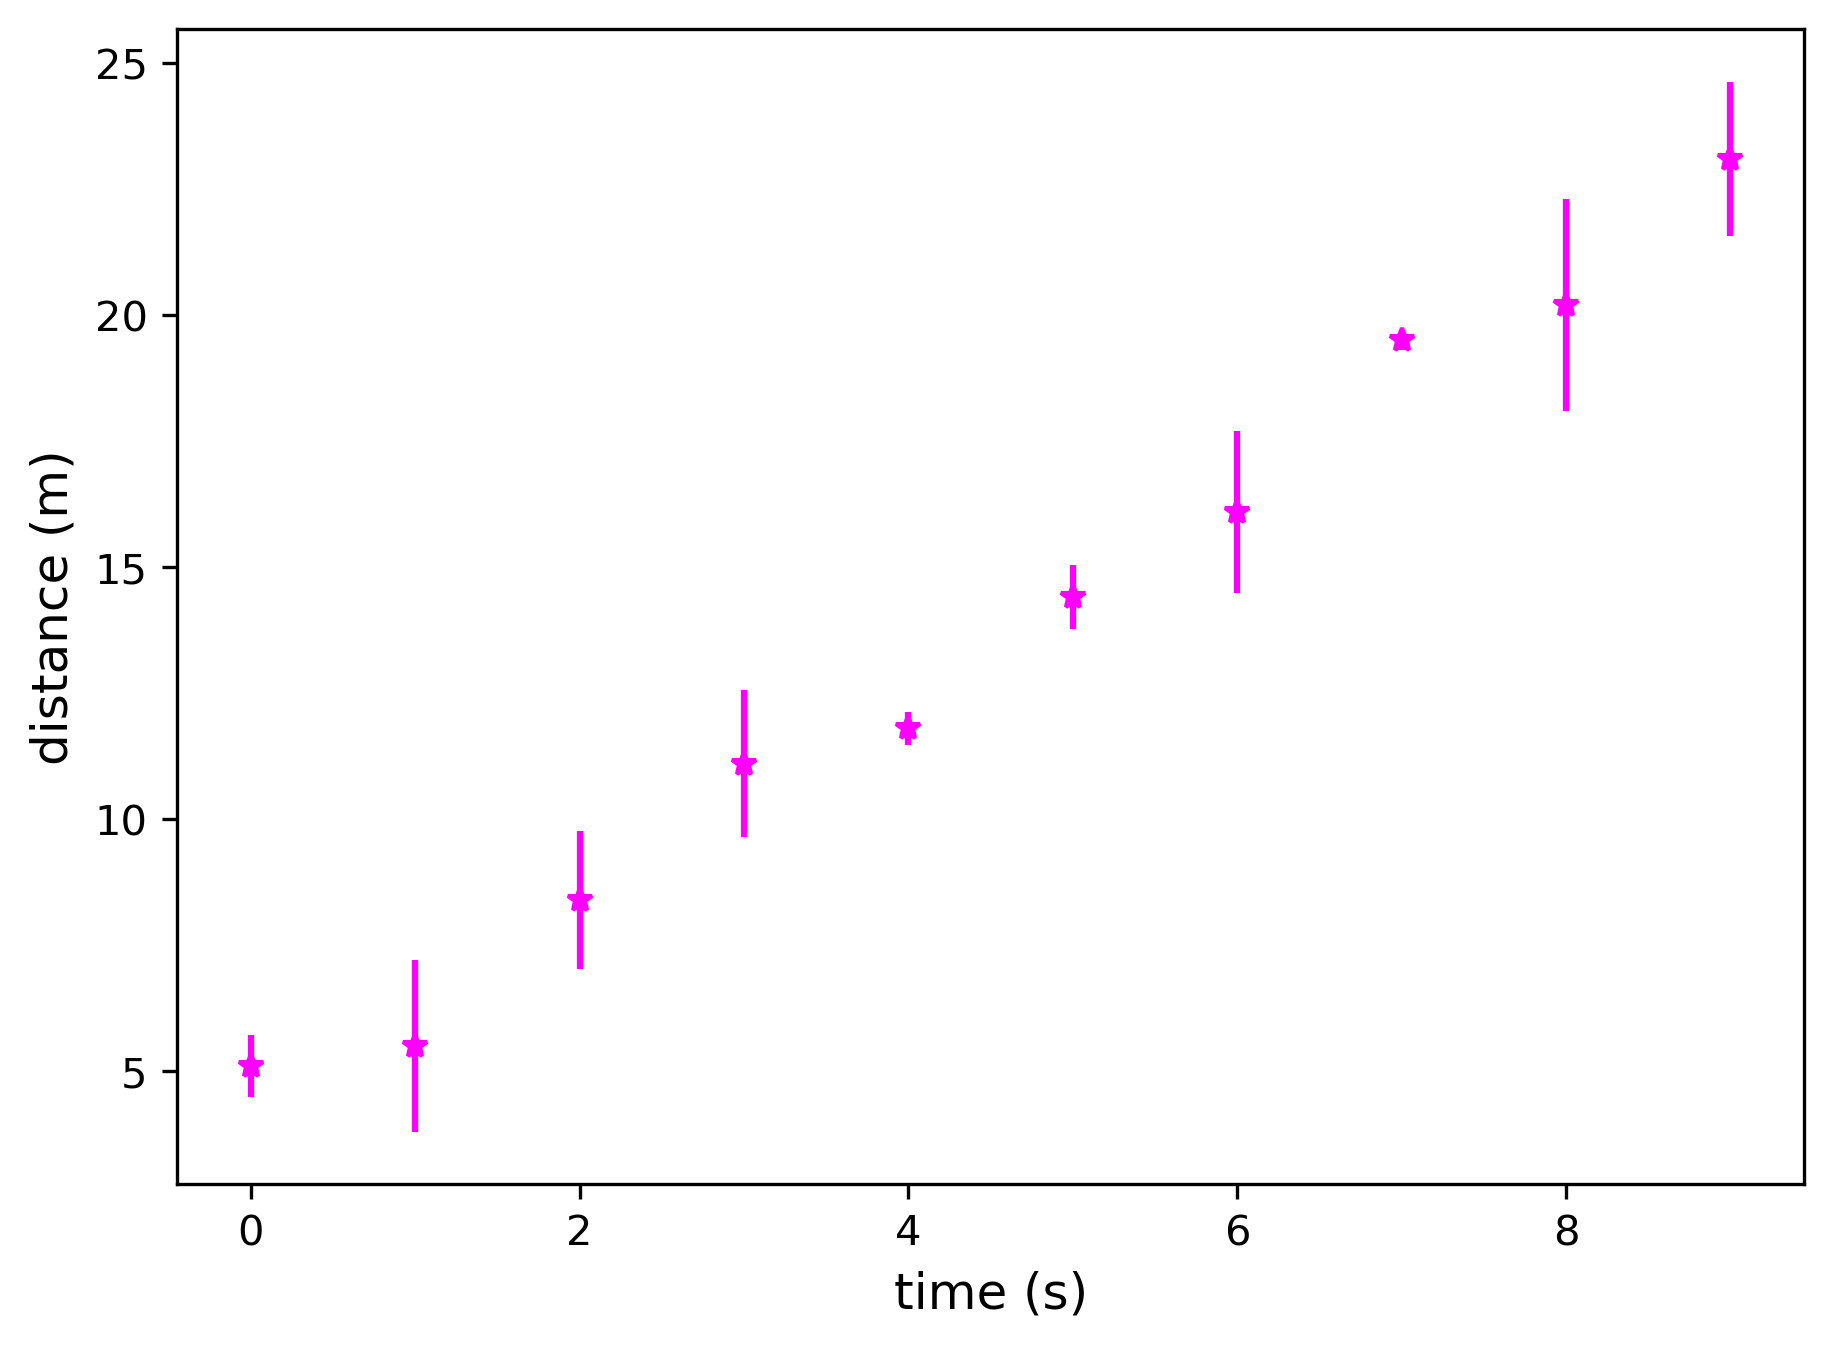

In [56]:
#Se muestran los datos con las incertezas aleatorias
plt.figure(figsize=(7,5)) 
plt.errorbar(x,y, np.abs(dy), marker = '*', markersize = 6, c = 'fuchsia', linestyle = ' ')
plt.xlabel('time (s)')
plt.ylabel('distance (m)')

<details>
<summary>Ayuda!</summary>
    Cuando agregamos incertezas, debemos considerar que datos con menor incerteza tienen más "peso". Para esto, modificaremos la función de error cuadrado con el inverso de los cuadrados de las distancias. Esto se conoce como distribución $\chi^2$ (likelihood)


Con el hint otorgado, para encontrar los parámetros de la mejor recta cuando se agregan incertezas, se deben considerar los datos con menor incerteza (osea datos más "relativamente exactos") que tengan más peso, o asimismo que impacten más en el ajuste. Se puede modificar la función de error cuadrado con el inverso de los cuadrados de las distancias, conocido como distribución $\chi^2$ (likelihood).

In [83]:
dy = np.random.randn(10)*np.sqrt(2) #se agrega la incerteza aleatoria
mm = np.polyfit(x,y,1,w=1/dy**2) #se obtiene ajuste asociado a los datos con incerteza considerando el peso
print(np.array(mm))
float(mm[0]),float(mm[1])

[2.10140363 4.63345561]


(2.1014036318471185, 4.633455608446176)

Así, se grafican los datos con incertezas y el nuevo ajuste considerando el peso.

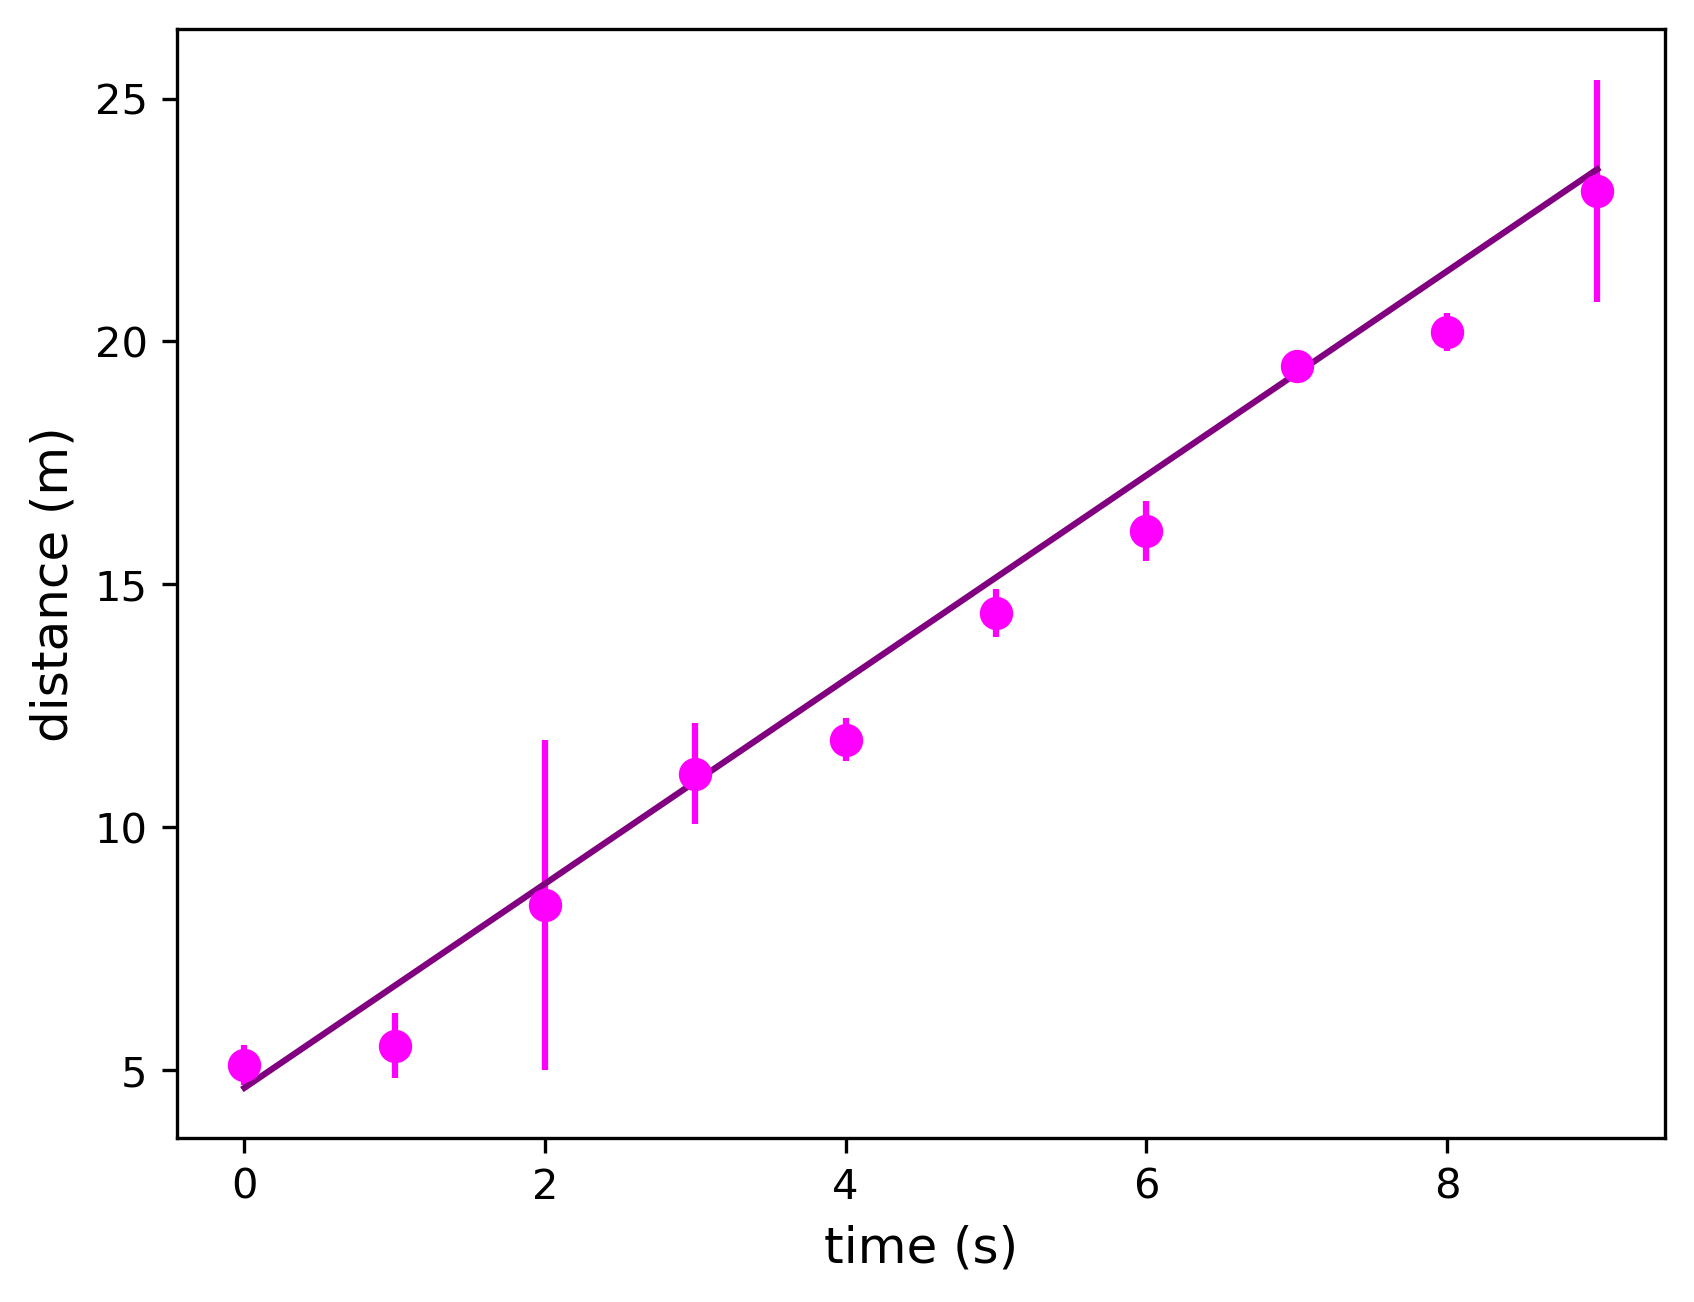

In [84]:
bestm_werr=float(mm[0])
bestb_werr=float(mm[1])
plt.errorbar(x,y, np.abs(dy), marker = 'o', markersize = 7, c = 'fuchsia', linestyle = ' ')
plt.xlabel('time (s)')
plt.ylabel('distance (m)')
plt.plot(x, bestb_werr + bestm_werr * x, c = 'purple') #agregue sus parámetros

Con ello, ambos modelos, los que tienen certezas e incertezas se pueden comparar.

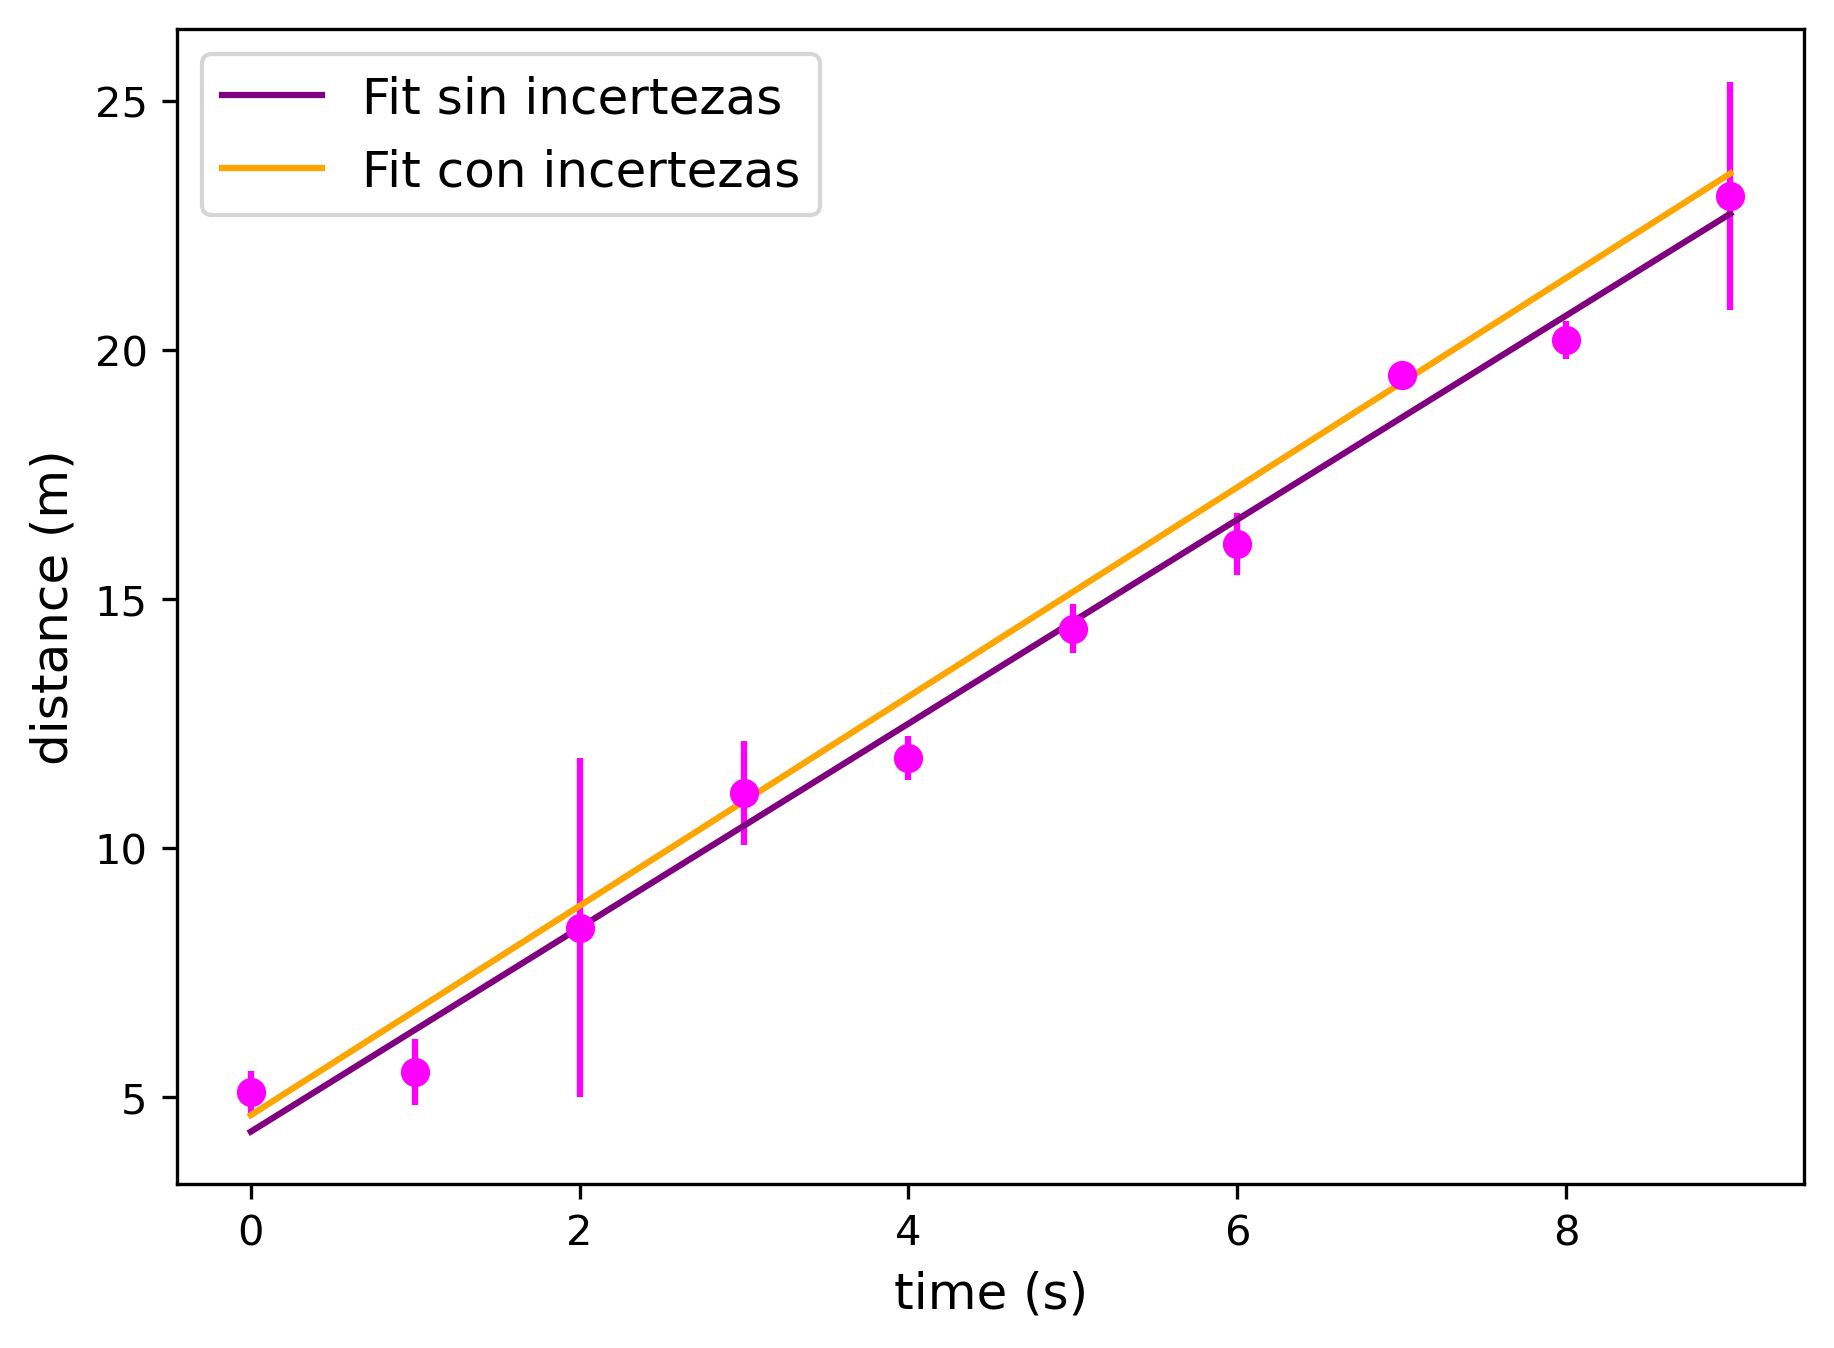

In [85]:
plt.figure(figsize=(7,5)) 
plt.errorbar(x,y, np.abs(dy), marker = 'o', markersize = 6, c = 'fuchsia', linestyle = ' ')
plt.plot(x, bestb + bestm * x, c = 'purple', label = 'Fit sin incertezas')
plt.plot(x, bestb_werr + bestm_werr * x, c = 'orange', label = 'Fit con incertezas')
plt.xlabel('time (s)')
plt.ylabel('distance (m)')
plt.legend()

**Pregunta: ¿Tiene sentido ese cambio?**

El cambio sí tiene sentido, dado que las líneas se ajustan de acuerdo al peso mayor o menos dependiendo de cual sea el error que tenga cada dato, para el fit con incertezas se observa que la distancia recorrida (como target, variable continua realizada para 10 instancias) es un poco mayor que el fit sin incertezas (donde se tienen todos los datos con pesos iguales). Al tener que la incertidumbre sea menor (barras de error más pequeñas) entonces mayor es el peso, y viceversa, si la incertidumbre es mayor entonces el peso que tiene el dato en menor. Para el que tiene más peso, domina. Por ejemplo, para t=2 s y t=9 s (considerando el tiempo como feature), el peso no es tanto comparado con los otros puntos donde las incertidumbres son menores. Entonces el cambio en las pendientes, puede ser por los datos generados aleatoriamente para los cuales, agregada la incerteza, se les otorga un peso diferente, es decir, la ponderación de estos, respecto a los que no la tienen.


<h2 style="color:Fuchsia; font-family:; text-align:center;font-size:20px">
  ❁۪ ｡˚ Parte 2: Machine Learning  ❁۪ ｡˚
</h2>

Si queremos resolver la pregunta de $d(t=12 s)=?$ usando aprendizaje de máquinas, la estrategia no es escribir explícitamente el modelo, ni los parámetros o el likelihood (aunque la elección de modelo sí afecta el resultado y la habilidad de aprender de los datos de entrenamiento).

En este caso, tenemos un problema de aprendizaje supervisado, donde nuestro set de datos inicial son los datos de aprendizaje. Debemos dividir estos datos en un conjunto de entrenamiento y prueba, de forma aleatoria (en el caso de una serie de tiempo esto no es verdad, pero en este caso no importa).

Consideraremos que nuestro problema es de regresión, porque la variable "target" es continua. Probaremos con dos modelos muy simples: Regresión lineal y Árbol de Decisión.

Desde la librería Sci-kit learn se importan los modelos que ya fueron implementados y se usan funciones de la librería para separar los datos en entrenamiento y prueba a partir de nuestros datos de distancia y tiempo creados al inicio del notebook.

In [79]:
from sklearn.tree import DecisionTreeRegressor #modelo de árbol de decisión

In [80]:
from sklearn.linear_model import LinearRegression #modelo de regresión lineal

In [81]:
from sklearn.model_selection import train_test_split  #para dividir los datos

In [86]:
np.random.seed(10) #de nuevo, se aplica la semilla fija para reproducibilidad
#A continuación se crean sets de entrenamiento/prueba
X_train, X_test, y_train, y_test = train_test_split(x,y, test_size=3) 

In [90]:
X_train, y_train #se producen 7 datos de entrenamiento y se muestran en array

(array([6, 3, 1, 0, 7, 4, 9]),
 array([16.1, 11.1,  5.5,  5.1, 19.5, 11.8, 23.1]))

In [91]:
X_test,y_test #3 de prueba x=8,x=2,x=5, se muestran como array

(array([8, 2, 5]), array([20.2,  8.4, 14.4]))

In [92]:
#Inicialización del modelo
treemodel = DecisionTreeRegressor() # Objeto "Estimator" de sklearn, con default params

In [93]:
regmodel = LinearRegression() # Objeto "Estimator" de sklearn, con default params default params

El modelo se construye con los datos de entrenamiento y se usan para predecir el output en los datos de prueba.

In [98]:
#Predicciones de los datos usando árbol de decisión (treemodel)
y_pred_tree = treemodel.fit(X_train.reshape(-1, 1), y_train).predict(X_test.reshape(-1, 1))

In [99]:
#Predicción usando regresión lineal
y_pred_reg = regmodel.fit(X_train.reshape(-1, 1), y_train).predict(X_test.reshape(-1, 1))

In [100]:
#A continuación se tienen los valores reales/predichos por RL (regresión lineal) y AD (árbol de decisión)
#respectivamente
print(y_test, y_pred_reg, y_pred_tree) 

[20.2  8.4 14.4] [20.89279279  8.41981982 14.65630631] [19.5  5.5 11.8]


Se usa como métrica de evaluación los errores cuadrados promedio (MSE) para cada modelo (RL, AD)

In [105]:
#MSE para valor obtenido con modelo de predicción regresión lineal
np.mean((y_test-y_pred_reg)**2) #MSE, sum(yreal-ypred)**2  mean squared error

np.float64(0.18201586721857252)

In [106]:
#MSE para valor obtenido con modelo de predicción árbol de decisión
np.mean((y_test-y_pred_tree)**2)

np.float64(5.22)

**Pregunta: ¿Cuál modelo es mejor, RL o AD?**

Para decidir entre cuál modelo es mejor, se puede asociar el MSE pequeño, es decir, que las diferencias entre el valor creado real y el valor obtenido con el modelo son menores. Luego, el mejor modelo es el de regresión lineal (RL), la cual tiene como suposición la relación lineal entre una variable dependiente (distancia) con la variable independiente (tiempo), otorgando en esa métrica definida un mejor ajuste y desempeño a los test data, siendo superior al modelo AD, puesto que este último podría estar desestimando cada predicción.

Usamos el resultado para predecir $t = 12$ s con cada modelo

In [131]:
print("Valor obtenido para d(t=12 s) con AD:",float(treemodel.predict(np.array(12).reshape(-1, 1))[0]))
print("Valor obtenido para d(t=12 s) con RL:",float(regmodel.predict(np.array(12).reshape(-1, 1))[0]))

Valor obtenido para d(t=12 s) con AD: 23.1
Valor obtenido para d(t=12 s) con RL: 29.208108108108114


Con la comparacion de predicciones de modelo con los datos de prueba, versus los datos reales, utilizando los modelos, para RL el valor de d(t=12 s) es alrededor de 29.2 m y con el modelo de AD, es de 23.1 m. Mientras que con inferencia el valor fue 28.9 m.

<h2 style="color:purple; font-family:; text-align:center;font-size:26px">
  ❁۪ ｡˚ Conclusión  ❁۪ ｡˚
</h2>

Finalmente, cuál de las dos estrategias funcionó mejor, inferencia o ML?


Primero, se tienen que tener en cuenta los alcances de cada modelo y que cuentan con ventajas y desventajas. Por ejemplo, en la inferencia probabilística se ejecuta con una relación explícita de forma paramétrica encontrando los parámetros el modelo, pero eso se puede hacer cuando se sabe el concepto físico. En este caso, el modelo funciona mejor quizás. Pero también se tiene que considerar que puede existir otra función donde los parámetros que se obtuvieron no funcionarían bien en el modelo directo, luego no se podría predecir acerca del data set. También se considera "más fácil" de interpretar debido al conocimiento del concepto, computacionalmente es más costoso, o podría perderse información si es que los modelos son muy simple, etc.

Por otra parte, se encuentran los modelos pertenecientes a ML, donde los resultados son dependientes del algoritmo el cual "moldea" las mismas relaciones entre los datos. Si se tiene un data set pero no se sabe cómo funciona el concepto físico se puede utilizar ML pero con ciertas limitaciones, como la poca generalización, al tener un modelo se puede interpretar pero no es trivial, además resulta ser computacionalmente menos costoso, pero al mismo tiempo mezcla mucho data y algo podría perderse, entre otros.

Finalmente, la inferencia, posiblemente, podría ser el método que mejor funcionó, en nuestro caso debido a que se sabe el concepto físico, y se aplican incertezas asociadas a los datos, pero de igual forma se tiene que analizar el "conjunto" de prueba, como se había mencionado antes.

- Hubiera funcionado la inferencia estadística si hubiéramos usando un modelo distinto (e.g sinusoidal)?

Puede que no, porque dependería que tan "bien" represente el modelo utilizado o asismismo la función utilizada. Para el modelo sinusoidal, si los datos no son bien ajustados claramente por la forma de la función, la función no funcionaría, provocando un modelo incorrecto.


- En el caso de ML, cómo elegimos el mejor modelo?

Para escoger el mejor modelo se tienen que tener en cuenta las consideraciones y limitaciones para cada uno. En la regresión lineal (RL), como algoritmo fundamental de aprendizaje supervisado que permite modelar la relación entre la variable dependiente y una o más variables independientes, se formulan algunas hipótesis para garantizar la fiabilidad de los resultados del modelo, además de la predicción de valores continuos ajustando una línea recta, hay limitaciones (constraints) afectando posiblemente resultados finales; una es la suposición de linealidad, como método que presupone que las variables tienen una relación lineal. Si la relación no es lineal, la RL podría fallar o no funcionar bien en su totalidad. Por otra parte, también hay sensibilidad ante los valores atípicos, desviando el ajuste. También como parte de las suposiciones del modelo RL, están linealidad, independencia de errores; donde los errores de las predicciones no deben afectarse entre sí, una varianza constante; para lo cual los errores deben poseer la misma dispersión entre todos los valores de entrada, si la dispersión cambia es un problema para el modelo, hay también una distribución normal de los errores, entre otras limitaciones.

Por otra parte, en el mismo marco de modelo ML, pero ahora para el árbol de decisión, también un método de aprendizaje supervisado con aproximaciones "trozo a trozo", utiliza una "white box model", donde una situación observable está en un modelo, se puede explicar por la lógica booleana (como verdadero o falso). Pero tal como para RL, hay limitaciones, como no generalizar bien el data en su completitud, como hacer overfitting, también los árboles de decisiones pueden ser inestables por pequeñas variaciones en el data, las predicciones no son continuas ni suaves a lo largo de la predicción, puesto que considera trozo por trozo la aproximación, por tanto el AD no es bueno extrapolando, etc.


Luego, quizás el AD puede ser el mejor modelo puesto que tomaría por partes las aproximaciones, donde se tendrían los datos train y de prueba por separado para poderlos aplicar en cada modelo y entrenarlos con datos train. Posteriormente, evaluar el modelo con datos que no hayan estado en entrenamiento para predecir el modelo, y en la métrica obtener un MSE de acuerdo a los datos y observados, ante la cantidad total de datos, y el que tenga menor MSE (menores diferencias entre dato y dato) puede ser el que mejor prediga el modelo, junto a ello ver cuál modelo generaliza mejor los datos que no fueron utilizados durante el entrenamiento y que cumpla con las suposiciones mencionadas anteriormente. Para el análisis más completo, se puede hacer un cross-validation, osea se agrupan los datos o se hacen particiones para no tener una única "posibilidad" a seguir durante el proceso. Además, para una mejor "discriminación" de modelos, se tienen que usar distintos datos tanto de prueba como train, para que se pueda concluir bien acerca del resultado final de selección.

Luego, como un hint se presenta a partir de la actividad la "discriminación" de cuál modelo funciona mejor para la interpretabilidad, predicción y contexto del problema.
**¿Cuál funciona mejor?**
- Mejor para Interpretabilidad: Si el objetivo es entender las relaciones entre variables y poder explicar esas relaciones de manera clara y comprensible, la inferencia estadística puede ser más adecuada. Esto es común en estudios científicos donde la interpretabilidad es clave.

- Mejor para Predicción: Si el objetivo es lograr la mejor precisión predictiva posible, especialmente con datos complejos y de gran escala, los métodos de aprendizaje automático tienden a ser más efectivos. Modelos como árboles de decisión, random forests, y redes neuronales suelen superar a los modelos estadísticos clásicos en tareas predictivas.

- Contexto del Problema: En problemas donde se necesita tanto interpretación como precisión, puede ser útil usar ambos enfoques. Por ejemplo, comenzar con modelos de inferencia para explorar los datos y entender las relaciones básicas, y luego usar ML para optimizar la precisión predictiva.

<h2 style="color:purple; font-family:; text-align:center;font-size:26px">
  ❁۪ ｡˚ Referencias  ❁۪ ｡˚
</h2>
Acquaviva, V. 2023. Machine Learning for Physics and Astronomy

\\

https://www.geeksforgeeks.org/machine-learning/ml-linear-regression/

\\

https://scikit-learn.org/stable/modules/tree.html